#### Untuk melihat dashboard dan model prediksi kepadatan dapat di lihat di : https://github.com/Firdausizm/Project_compiler_2026

# Load dataset

In [1]:
import pandas as pd
import numpy as np
import datetime
import os

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

file_path = "dfTransjakarta.csv"
if not os.path.exists(file_path):
    print(f"Error: {file_path} not found.")
    exit(1)

df = pd.read_csv(file_path)
print(f"Original shape: {df.shape}")

Original shape: (37900, 22)


# Dataframe info

In [2]:
df.head()

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount
0,EIIW227B8L34VB,180062659848800,emoney,Bajragin Usada,M,2008,5,Matraman Baru - Ancol,1.0,P00142,...,106.84402,7,2023-04-03 05:21:44,P00253,Tegalan,-6.203101,106.85715,12.0,2023-04-03 06:00:53,3500.0
1,LGXO740D2N47GZ,4885331907664776,dki,Gandi Widodo,F,1997,6C,Stasiun Tebet - Karet via Patra Kuningan,0.0,B01963P,...,106.83302,13,2023-04-03 05:42:44,B03307P,Sampoerna Strategic,-6.217152,106.81892,21.0,2023-04-03 06:40:01,3500.0
2,DJWR385V2U57TO,4996225095064169,dki,Emong Wastuti,F,1992,R1A,Pantai Maju - Kota,0.0,B00499P,...,106.81435,38,2023-04-03 05:59:06,B04962P,Simpang Kunir Kemukus,-6.133731,106.81475,39.0,2023-04-03 06:50:55,3500.0
3,JTUZ800U7C86EH,639099174703,flazz,Surya Wacana,F,1978,11D,Pulo Gebang - Pulo Gadung 2 via PIK,0.0,B05587P,...,106.93526,23,2023-04-03 05:44:51,B03090P,Raya Penggilingan,-6.183068,106.93194,29.0,2023-04-03 06:28:16,3500.0
4,VMLO535V7F95NJ,570928206772,flazz,Embuh Mardhiyah,M,1982,12,Tanjung Priok - Pluit,0.0,P00239,...,106.88900,5,2023-04-03 06:17:35,P00098,Kali Besar Barat,-6.135355,106.81143,15.0,2023-04-03 06:57:03,3500.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37900 entries, 0 to 37899
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transID           37900 non-null  object 
 1   payCardID         37900 non-null  int64  
 2   payCardBank       37900 non-null  object 
 3   payCardName       37900 non-null  object 
 4   payCardSex        37900 non-null  object 
 5   payCardBirthDate  37900 non-null  int64  
 6   corridorID        36643 non-null  object 
 7   corridorName      35970 non-null  object 
 8   direction         37900 non-null  float64
 9   tapInStops        36687 non-null  object 
 10  tapInStopsName    37900 non-null  object 
 11  tapInStopsLat     37900 non-null  float64
 12  tapInStopsLon     37900 non-null  float64
 13  stopStartSeq      37900 non-null  int64  
 14  tapInTime         37900 non-null  object 
 15  tapOutStops       35611 non-null  object 
 16  tapOutStopsName   36556 non-null  object

In [4]:
df['payCardBank'].unique()

array(['emoney', 'dki', 'flazz', 'online', 'brizzi', 'bni'], dtype=object)

In [5]:
summary = pd.DataFrame({
    'Column': df.columns,
    'Non-Null': df.notnull().sum(),
    'Null': df.isnull().sum(),
    'Dtype': df.dtypes
})

summary

,Column,Non-Null,Null,Dtype
transID,transID,37900,0,object
payCardID,payCardID,37900,0,int64
payCardBank,payCardBank,37900,0,object
payCardName,payCardName,37900,0,object
payCardSex,payCardSex,37900,0,object
payCardBirthDate,payCardBirthDate,37900,0,int64
corridorID,corridorID,36643,1257,object
corridorName,corridorName,35970,1930,object
direction,direction,37900,0,float64
tapInStops,tapInStops,36687,1213,object


# Cleaning data

In [6]:
# 2. Convert Datetime
df['tapInTime'] = pd.to_datetime(df['tapInTime'], errors='coerce')
df['tapOutTime'] = pd.to_datetime(df['tapOutTime'], errors='coerce')

# pisah tahun bulan, tanggal, jam dan menit pada tapInTime dan tapOutTime
df['tapInYear'] = df['tapInTime'].dt.year
df['tapInMonth'] = df['tapInTime'].dt.month
df['tapInDate'] = df['tapInTime'].dt.day
df['tapInHour'] = df['tapInTime'].dt.hour
df['tapInMinute'] = df['tapInTime'].dt.minute

df['tapOutYear'] = df['tapOutTime'].dt.year
df['tapOutMonth'] = df['tapOutTime'].dt.month
df['tapOutDate'] = df['tapOutTime'].dt.day
df['tapOutHour'] = df['tapOutTime'].dt.hour
df['tapOutMinute'] = df['tapOutTime'].dt.minute

# 3. Handle Missing Values
# jika tapinstopsname dan tapintime datanya kosong maka baris itu tidak valid dan harus di drop
df = df.dropna(subset=['tapInStopsName', 'tapInTime'])

# Featutre enggineering

In [7]:
# hitung durasi perjalanan dalam menit
df['trip_duration_mins'] = (df['tapOutTime'] - df['tapInTime']).dt.total_seconds() / 60.0

# isi negatif atau 0 di trip_duration_mins dan menghapus perjalanan yang lebih dr 5 jam(outlier)
df = df[(df['trip_duration_mins'] > 0) & (df['trip_duration_mins'] < 300) | (df['trip_duration_mins'].isna())]

# Extract jam dan hari dalam seminggu
df['tapInDayOfWeek'] = df['tapInTime'].dt.dayofweek # 0=Monday, 6=Sunday
df['tapInDayName'] = df['tapInTime'].dt.day_name()

# Handle Outliers di payAmount
# Asumsi normal payAmount di antara 0 dan 20.000   (btw ini harus di crossceck lagi)
df = df[(df['payAmount'] >= 0) & (df['payAmount'] <= 20000) | (df['payAmount'].isna())]

# Handle Birth Date / Age
current_year = df['tapInTime'].dt.year.max()
if pd.isna(current_year):
    current_year = 2023 # default dari dataset

df['payCardBirthDate'] = pd.to_numeric(df['payCardBirthDate'], errors='coerce')
df['age'] = current_year - df['payCardBirthDate']
# Filter ages
df.loc[(df['age'] < 5) | (df['age'] > 100), 'age'] = np.nan

# save clean dataset

In [8]:
df_clean = df

cleaned_file = "dfTransjakarta_cleaned.csv"
df_clean.to_csv(cleaned_file, index=False)
print(f"Cleaned dataset saved to {cleaned_file}. Shape: {df_clean.shape}")

Cleaned dataset saved to dfTransjakarta_cleaned.csv. Shape: (37900, 36)


# visualisasi data

In [9]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37900 entries, 0 to 37899
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transID             37900 non-null  object        
 1   payCardID           37900 non-null  int64         
 2   payCardBank         37900 non-null  object        
 3   payCardName         37900 non-null  object        
 4   payCardSex          37900 non-null  object        
 5   payCardBirthDate    37900 non-null  int64         
 6   corridorID          36643 non-null  object        
 7   corridorName        35970 non-null  object        
 8   direction           37900 non-null  float64       
 9   tapInStops          36687 non-null  object        
 10  tapInStopsName      37900 non-null  object        
 11  tapInStopsLat       37900 non-null  float64       
 12  tapInStopsLon       37900 non-null  float64       
 13  stopStartSeq        37900 non-null  int64     

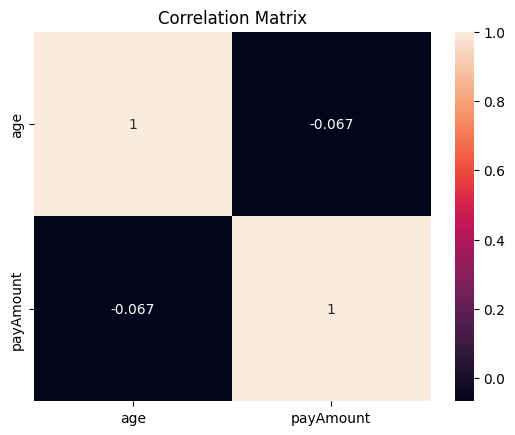

In [ ]:
num_cols = ['age', 'payAmount']   # payCardBank walau setelah di onehot encoder tetep ga bisa woe karena datanya bool dan aku masi belum nemu solusi

# Corelation Matrix
plt.figure()
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

# Nyiapin buat predict kepadatan penumpang di halte, hari dan jam tertentu

In [11]:
# keompokan berdasarkan nama pemberhentian, hari adn tapin jam tertentu
density_df = df_clean.groupby(['tapInStopsName', 'tapInDayOfWeek', 'tapInHour']).size().reset_index(name='passenger_count')

# save
density_file = "density_data.csv"
density_df.to_csv(density_file, index=False)
print(f"Density data saved to {density_file}. Shape: {density_df.shape}")

Density data saved to density_data.csv. Shape: (23364, 4)


# Business Insights

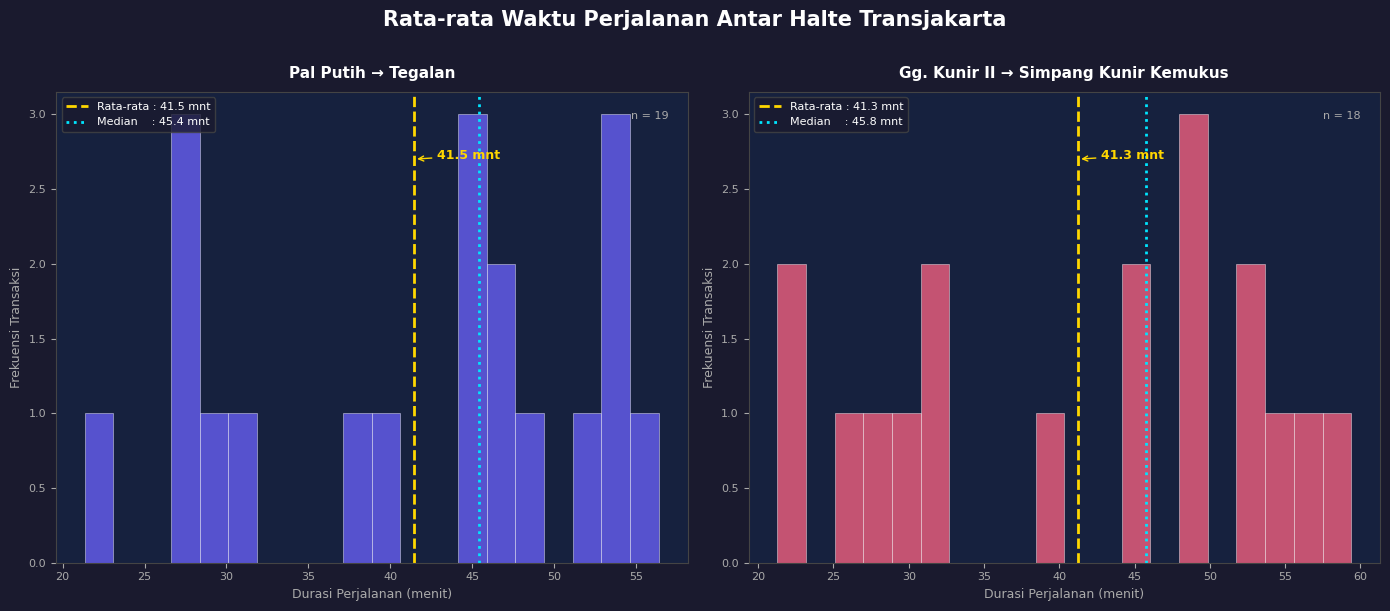

In [12]:
# Definisi rute
routes = [
    {
        'label':   'Pal Putih → Tegalan',
        'tap_in':  'Pal Putih',
        'tap_out': 'Tegalan',
        'color':   '#6C63FF',
    },
    {
        'label':   'Gg. Kunir II → Simpang Kunir Kemukus',
        'tap_in':  'Gg. Kunir II',
        'tap_out': 'Simpang Kunir Kemukus',
        'color':   '#FF6584',
    },
]

results       = []
distributions = []

for r in routes:
    mask = (
        (df_clean['tapInStopsName']  == r['tap_in']) &
        (df_clean['tapOutStopsName'] == r['tap_out']) &
        (df_clean['trip_duration_mins'] > 0) &
        (df_clean['trip_duration_mins'] < 300)
    )
    subset = df_clean.loc[mask, 'trip_duration_mins'].dropna()
    avg    = subset.mean()
    median = subset.median()
    count  = len(subset)
    results.append({'label': r['label'], 'avg_min': avg, 'median_min': median,
                    'count': count, 'color': r['color']})
    distributions.append(subset)

# Visualisasi
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#1A1A2E')
fig.suptitle('Rata-rata Waktu Perjalanan Antar Halte Transjakarta',
             fontsize=15, fontweight='bold', color='white', y=1.01)

for ax, res, dist in zip(axes, results, distributions):
    ax.set_facecolor('#16213E')

    if dist.empty:
        ax.text(0.5, 0.5, 'Tidak ada data\nuntuk rute ini',
                ha='center', va='center', color='white', fontsize=11)
        ax.set_title(res['label'], color='white', fontsize=11, fontweight='bold')
        continue

    # Histogram distribusi
    n, bins, patches = ax.hist(
        dist, bins=20, color=res['color'], alpha=0.75,
        edgecolor='white', linewidth=0.4
    )

    # Garis rata-rata & median
    ax.axvline(res['avg_min'],    color='#FFD700', lw=2.0, linestyle='--',
               label=f"Rata-rata : {res['avg_min']:.1f} mnt")
    ax.axvline(res['median_min'], color='#00E5FF', lw=2.0, linestyle=':',
               label=f"Median    : {res['median_min']:.1f} mnt")

    ax.set_title(res['label'], color='white', fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Durasi Perjalanan (menit)', color='#AAAAAA', fontsize=9)
    ax.set_ylabel('Frekuensi Transaksi',       color='#AAAAAA', fontsize=9)
    ax.tick_params(colors='#AAAAAA', labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')

    # Anotasi rata-rata
    ax.annotate(
        f"{res['avg_min']:.1f} mnt",
        xy=(res['avg_min'], n.max() * 0.9),
        xytext=(res['avg_min'] + (bins[-1]-bins[0])*0.04, n.max() * 0.9),
        color='#FFD700', fontsize=9, fontweight='bold', ha='left',
        arrowprops=dict(arrowstyle='->', color='#FFD700', lw=1.0)
    )

    ax.legend(fontsize=8, facecolor='#1A1A2E', edgecolor='#444444', labelcolor='white')
    ax.text(0.97, 0.96, f'n = {res["count"]:,}',
            transform=ax.transAxes, ha='right', va='top',
            color='#AAAAAA', fontsize=8)

plt.tight_layout()
plt.show()


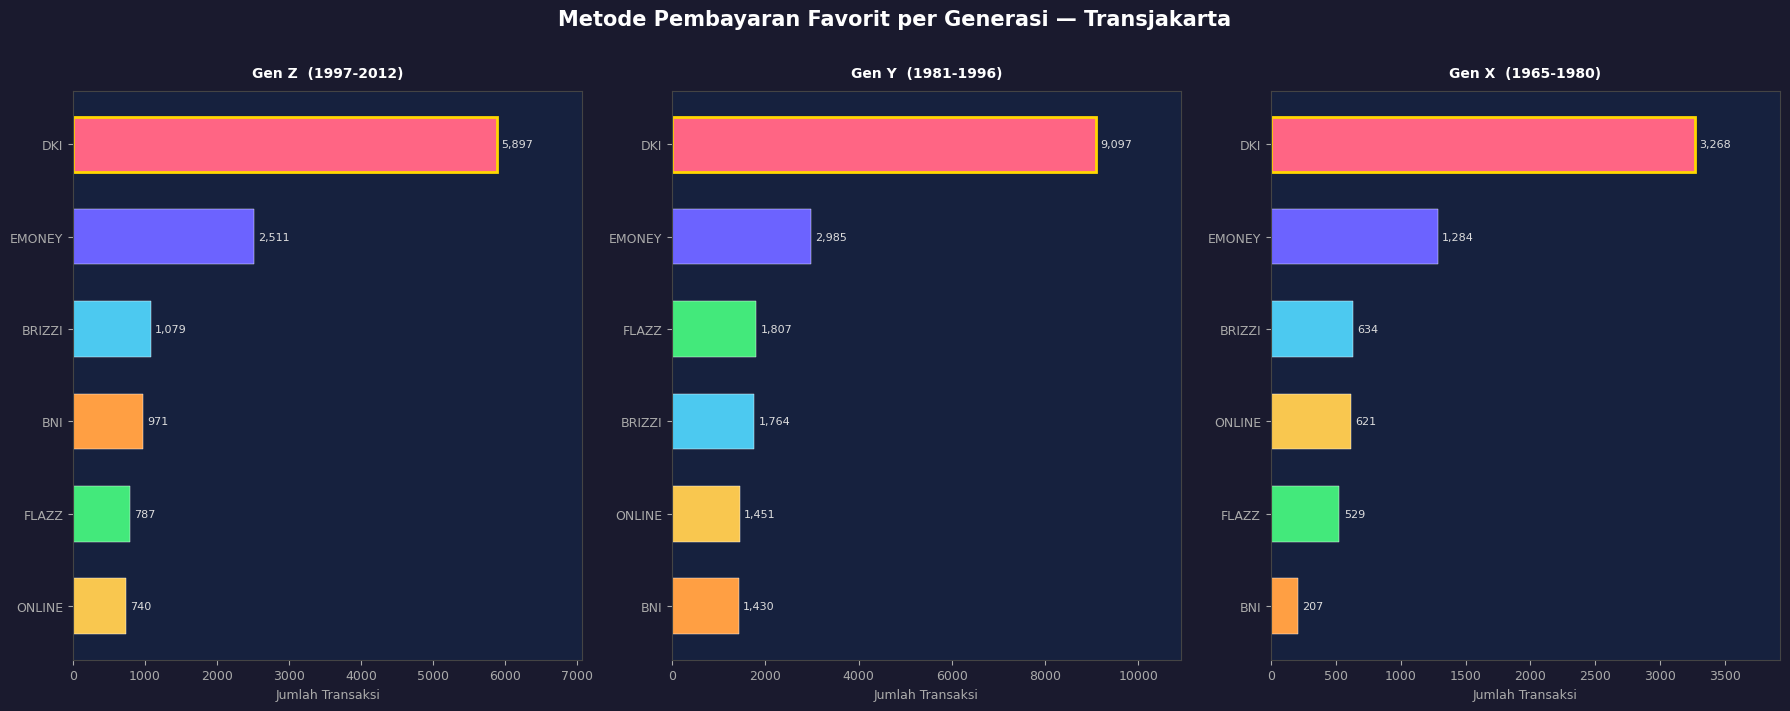

In [13]:
# Definisi rentang tahun lahir per generasi
gen_map = {
    'Gen Z  (1997-2012)': (1997, 2012),
    'Gen Y  (1981-1996)': (1981, 1996),
    'Gen X  (1965-1980)': (1965, 1980),
}

df_gen = df_clean[['payCardBirthDate', 'payCardBank']].dropna().copy()
df_gen['payCardBirthDate'] = pd.to_numeric(df_gen['payCardBirthDate'], errors='coerce')
df_gen['payCardBank'] = df_gen['payCardBank'].str.strip().str.lower()
df_gen = df_gen.dropna(subset=['payCardBirthDate'])

def assign_gen(year):
    for name, (lo, hi) in gen_map.items():
        if lo <= year <= hi:
            return name
    return None

df_gen['generation'] = df_gen['payCardBirthDate'].apply(assign_gen)
df_gen = df_gen.dropna(subset=['generation'])

# Warna per bank
bank_palette = {
    'emoney': '#6C63FF',
    'dki':    '#FF6584',
    'flazz':  '#43E97B',
    'online': '#F9C74F',
    'brizzi': '#4CC9F0',
    'bni':    '#FF9F43',
}

gen_order = list(gen_map.keys())
gen_data  = (
    df_gen.groupby(['generation', 'payCardBank'])
          .size()
          .reset_index(name='count')
)

# Visualisasi
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor('#1A1A2E')
fig.suptitle('Metode Pembayaran Favorit per Generasi — Transjakarta',
             fontsize=15, fontweight='bold', color='white', y=1.01)

for ax, gen in zip(axes, gen_order):
    sub = (
        gen_data[gen_data['generation'] == gen]
        .sort_values('count', ascending=False)
        .reset_index(drop=True)
    )
    ax.set_facecolor('#16213E')

    if sub.empty:
        ax.text(0.5, 0.5, 'Tidak ada data', ha='center', va='center', color='white')
        ax.set_title(gen.strip(), color='white', fontsize=10, fontweight='bold')
        continue

    banks  = sub['payCardBank'].str.upper().tolist()
    counts = sub['count'].tolist()
    colors = [bank_palette.get(b.lower(), '#888888') for b in sub['payCardBank']]

    # Horizontal bar chart (diurutkan dari kecil ke besar agar terpopuler di atas)
    bars = ax.barh(
        banks[::-1], counts[::-1], color=colors[::-1],
        edgecolor='white', linewidth=0.3, height=0.6
    )

    # Highlight bar terbesar (index -1 setelah pembalikan = terbesar)
    bars[-1].set_edgecolor('#FFD700')
    bars[-1].set_linewidth(2.0)

    # Label nilai di kanan bar
    for bar, cnt in zip(bars, counts[::-1]):
        ax.text(
            bar.get_width() + counts[0] * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{cnt:,}', va='center', color='#DDDDDD', fontsize=8
        )

    ax.set_title(gen.strip(), color='white', fontsize=10, fontweight='bold', pad=10)
    ax.set_xlabel('Jumlah Transaksi', color='#AAAAAA', fontsize=9)
    ax.tick_params(colors='#AAAAAA', labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')
    ax.set_xlim(0, counts[0] * 1.20)


plt.tight_layout()
plt.show()
